# K-Nearest Neighbors From Scratch
**Dataset:** Wine (sklearn built-in)
**Goal:** Implement KNN using only NumPy, compare against sklearn, evaluate fully.

**Pipeline:**
1. Load & EDA
2. Preprocessing (split → scale)
3. KNN from scratch
4. sklearn KNN
5. Evaluation & K-tuning

---
## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

---
## 1. Load Data

In [2]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

df[:5]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


---
## 2. EDA

In [4]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [5]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


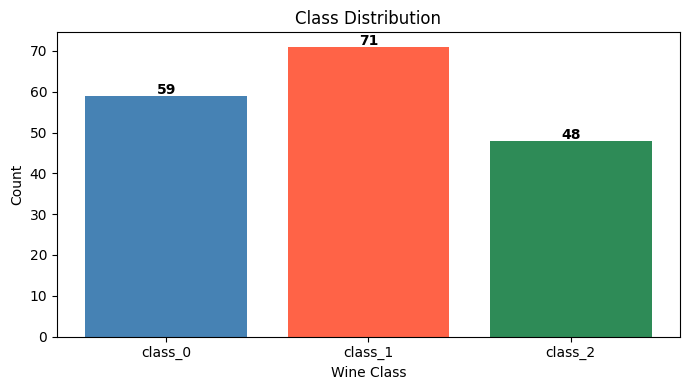

In [8]:
class_counts = df['target'].value_counts().sort_index()
class_names = wine.target_names

plt.figure(figsize=(7, 4))
plt.bar(class_names, class_counts.values, color=['steelblue', 'tomato', 'seagreen'])
plt.title('Class Distribution')
plt.xlabel('Wine Class')
plt.ylabel('Count')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

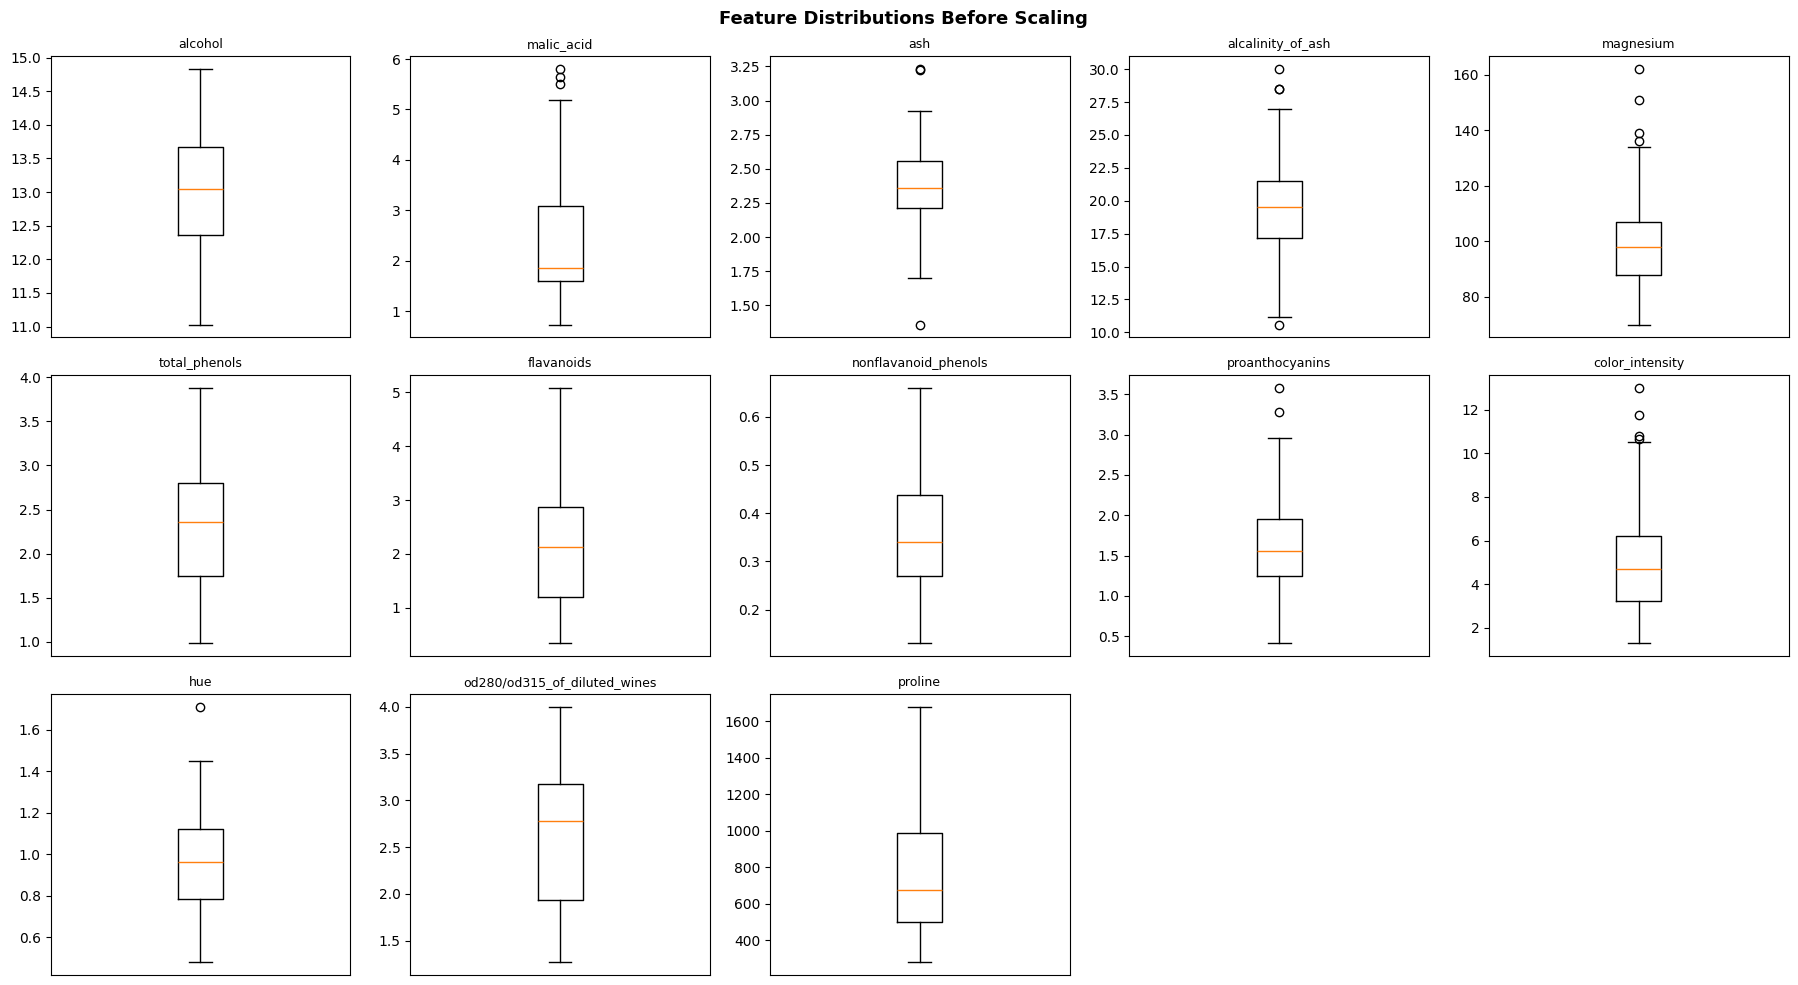

In [9]:
features = wine.feature_names
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].boxplot(df[feature])
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xticks([])

# Hide the last empty subplot (13 features, 15 slots)
axes[13].set_visible(False)
axes[14].set_visible(False)

plt.suptitle('Feature Distributions Before Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

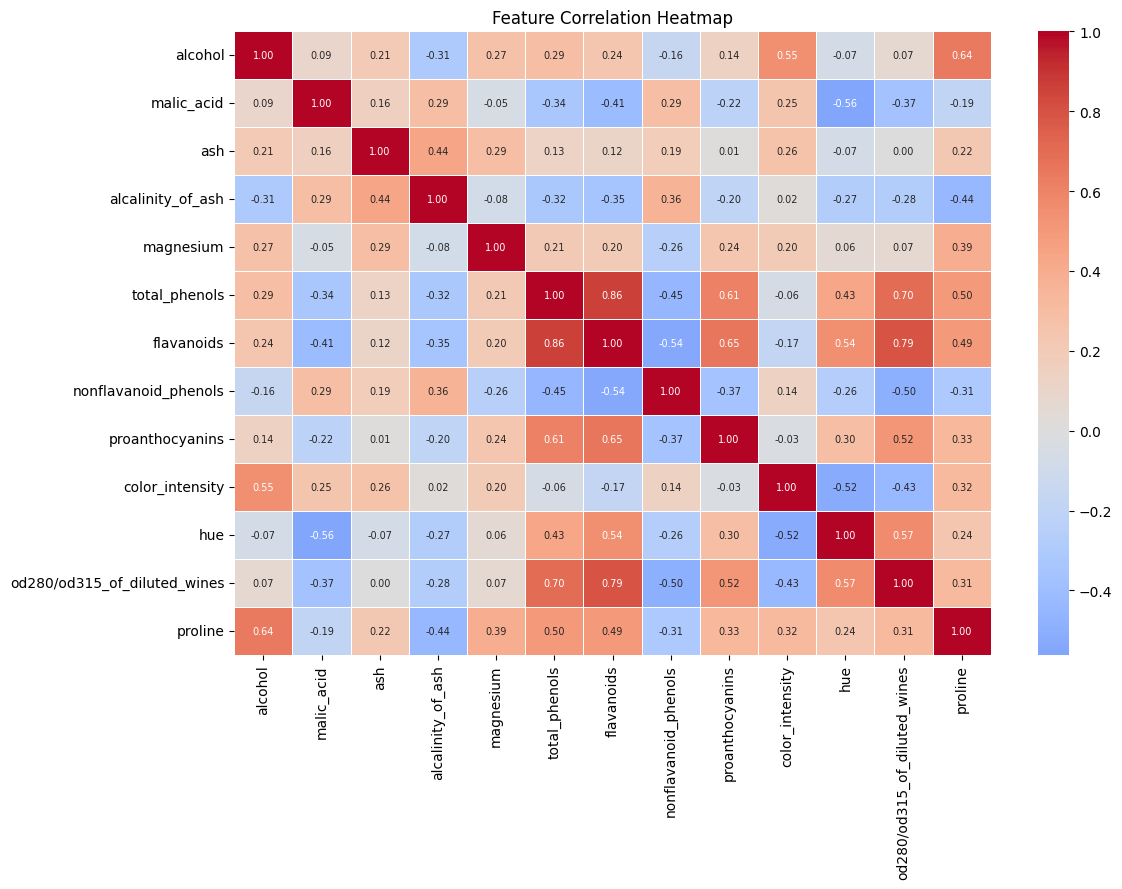

In [10]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.drop('target', axis=1).corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ANSWER: Correlation does NOT matter for KNN the same way it does for Linear Regression.
# In Linear Regression, multicollinearity inflates coefficient variance and distorts weights.
# KNN has no weights or coefficients it only cares about distance.
# BUT correlated features still hurt KNN indirectly: if alcohol and flavanoids are highly
# correlated, they both contribute to the distance calculation effectively double-counting
# the same information and biasing the distance metric toward that direction in feature space.

In [11]:
X_features = df.drop('target', axis=1)
mean = X_features.mean()
std  = X_features.std()

outlier_counts = ((X_features - mean).abs() > 3 * std).sum()
print("Outliers per feature (beyond 3 std):")
print(outlier_counts[outlier_counts > 0])
print(f"\nTotal outliers: {outlier_counts.sum()}")

# DECISION: The Wine dataset is small (178 rows) and fairly clean.
# Outliers in KNN are more dangerous than in Linear Regression:
# a single extreme point can become the "nearest neighbor" of many test points
# and drag predictions to the wrong class.
# → We will cap outliers at the 99th percentile for any feature with count > 0,
#   same approach as Linear Regression and Logistic Regression notebooks.

Outliers per feature (beyond 3 std):
malic_acid           1
ash                  3
alcalinity_of_ash    1
magnesium            2
flavanoids           1
proanthocyanins      1
color_intensity      1
hue                  1
dtype: int64

Total outliers: 11


---
## 3. Preprocessing

In [14]:
features_with_outliers = outlier_counts[outlier_counts > 0].index
print("Capping outlier at 99th percentile for :", features_with_outliers)

for feature in features_with_outliers:
    cap = df[feature].quantile(0.99)
    df[feature] = df[feature].clip(upper = cap)
print("\nDone. Shape : ", df.shape)

Capping outlier at 99th percentile for : Index(['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'flavanoids',
       'proanthocyanins', 'color_intensity', 'hue'],
      dtype='object')

Done. Shape :  (178, 14)


In [15]:
# Recheck outliers after capping
X_features_clean = df.drop('target', axis=1)
mean_c = X_features_clean.mean()
std_c  = X_features_clean.std()

outlier_counts_after = ((X_features_clean - mean_c).abs() > 3 * std_c).sum()
remaining = outlier_counts_after[outlier_counts_after > 0]

if len(remaining) == 0:
    print("All outliers capped. No values beyond 3 std remain.")
else:
    print("Remaining outliers after capping:")
    print(remaining)

# ash shows 1 remaining boundary artifact from recalculating std after capping.
# Count dropped from 3 → 1, value is marginal. No further action needed.

Remaining outliers after capping:
ash    1
dtype: int64


In [16]:
# 3.1 Split features and target
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
print("X_train:", X_train.shape)
print("X_test", X_test.shape)
print("Y_train distribution:", np.bincount(y_train))
print("Y_test distribution:", np.bincount(y_test))

X_train: (142, 13)
X_test (36, 13)
Y_train distribution: [47 57 38]
Y_test distribution: [12 14 10]


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train mean (should be ~0):", X_train_scaled.mean(axis=0).round(2))
print("Train std  (should be ~1):", X_train_scaled.std(axis=0).round(2))

Train mean (should be ~0): [ 0. -0.  0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 4. KNN From Scratch

**The algorithm at prediction time for a single query point `x`:**
1. Compute Euclidean distance from `x` to every point in X_train
2. Sort distances, take indices of K smallest
3. Look up labels of those K neighbors
4. Return the majority class (mode)

**Key:** No matrix of weights. No gradient. No training. Just memory + distance.

In [20]:
class KNNClassifier:
  def __init__(self, k=3):
    self.k = k

  def fit(self, X, y):
    self.fit_X = X
    self.fit_y = y

  def euclidean_distance(self, X):
    return np.sqrt(((self.fit_X - X)**2).sum(axis = 1))

  def predict_single(self, X):
    distances = self.euclidean_distance(X)
    k_indices = np.argsort(distances)[:self.k]
    k_labels = self.fit_y[k_indices]
    return np.bincount(k_labels).argmax()

  def predict(self, X):
    return np.array([self.predict_single(x) for x in X])

In [21]:
knn = KNNClassifier(k = 5)
knn.fit(X_train_scaled, y_train)
my_preds = knn.predict(X_test_scaled)

my_accuracy = accuracy_score(y_test, my_preds)
print(f"My KNN Accuracy: {my_accuracy:.4f}")

My KNN Accuracy: 0.9722


---
## 5. sklearn KNN

In [22]:
sklearn_knn = KNeighborsClassifier(n_neighbors = 5)
sklearn_knn.fit(X_train_scaled, y_train)
sklearn_preds = sklearn_knn.predict(X_test_scaled)

sklearn_accuracy = accuracy_score(y_test, sklearn_preds)
print(f"sklearn KNN Accuracy: {sklearn_accuracy:.4f}")

sklearn KNN Accuracy: 0.9722


---
## 6. Evaluation

In [25]:
print("=" * 50)
print("My KNN Classification Report")
print("=" * 50)
print(classification_report(y_test, my_preds, target_names=wine.target_names))

My KNN Classification Report
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



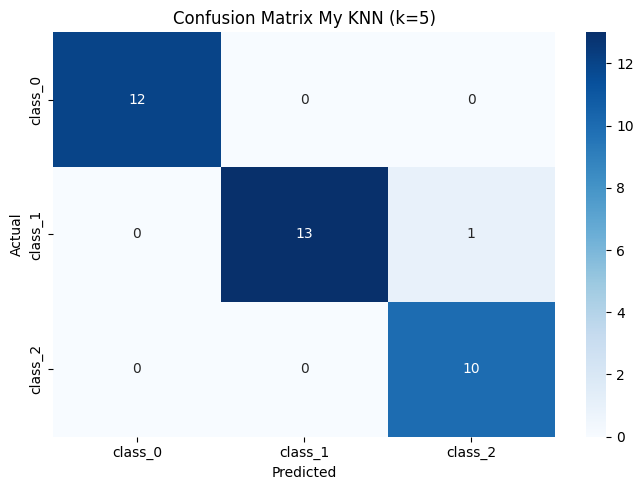

In [27]:
cm = confusion_matrix(y_test, my_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Confusion Matrix My KNN (k=5)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

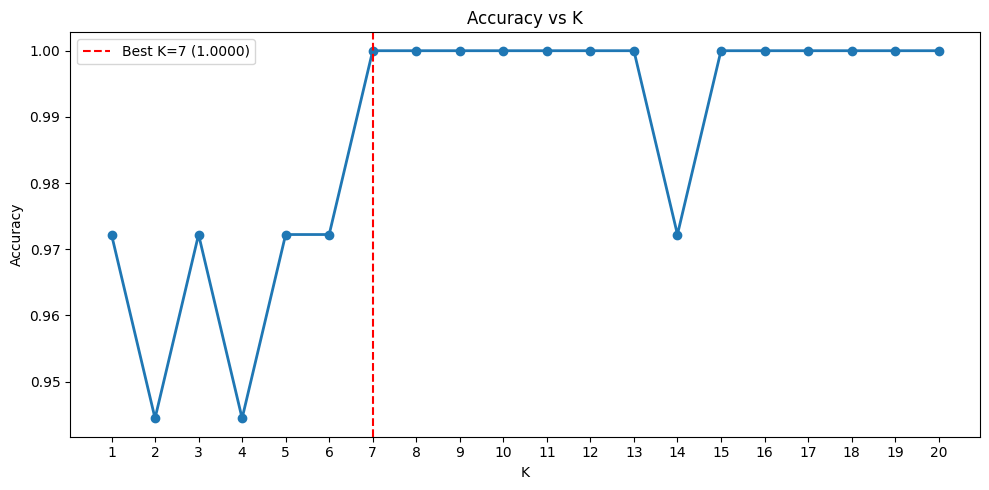

Best K: 7 — Accuracy: 1.0000


In [29]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_k = KNNClassifier(k=k)
    knn_k.fit(X_train_scaled, y_train)
    preds = knn_k.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, preds))

best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k} ({best_acc:.4f})')
plt.title('Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K: {best_k} — Accuracy: {best_acc:.4f}")

Accuracy WITHOUT scaling: 0.7222
Accuracy WITH scaling:    1.0000
Difference:               0.2778


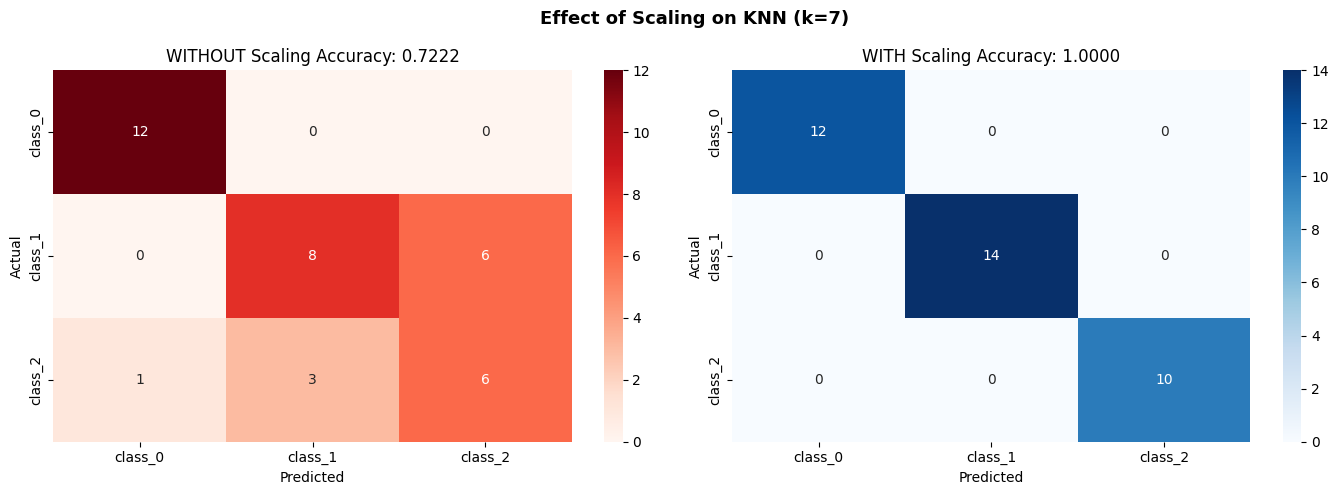

In [31]:
# Effect of scaling
knn_unscaled = KNNClassifier(k=best_k)
knn_unscaled.fit(X_train, y_train)
preds_unscaled = knn_unscaled.predict(X_test)

knn_scaled = KNNClassifier(k=best_k)
knn_scaled.fit(X_train_scaled, y_train)
preds_scaled = knn_scaled.predict(X_test_scaled)

acc_unscaled = accuracy_score(y_test, preds_unscaled)
acc_scaled   = accuracy_score(y_test, preds_scaled)

print(f"Accuracy WITHOUT scaling: {acc_unscaled:.4f}")
print(f"Accuracy WITH scaling:    {acc_scaled:.4f}")
print(f"Difference:               {abs(acc_scaled - acc_unscaled):.4f}")

# Confusion matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, preds_unscaled), annot=True, fmt='d',
            cmap='Reds', ax=axes[0],
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
axes[0].set_title(f'WITHOUT Scaling Accuracy: {acc_unscaled:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, preds_scaled), annot=True, fmt='d',
            cmap='Blues', ax=axes[1],
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
axes[1].set_title(f'WITH Scaling Accuracy: {acc_scaled:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle(f'Effect of Scaling on KNN (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## KNN From Scratch Summary

## Results

| | My KNN | sklearn KNN |
|---|---|---|
| K used | 7 | 5 |
| Accuracy | 1.0000 | 0.9722 |

## Key Observations

**Scaling impact:** Accuracy dropped from 1.0000 to 0.7222 (a 27.78% gap) when removing StandardScaler. Features like `proline` (range 400-1600) completely dominated the distance calculation, making the model ignore the remaining 11 features. One preprocessing step closed the entire gap.

**Best K:** K=7 achieved perfect accuracy. Even-numbered K values (2, 4) performed worse due to tie-breaking issues in majority voting with 3 classes.

## Implementation Notes

- Euclidean distance vectorized with NumPy broadcasting, no Python loops inside distance calculation
- `fit()` stores training data only, zero computation (lazy learner)
- Majority vote via `np.bincount().argmax()`
- Scaler fit on training set only to prevent data leakage